<a href="https://colab.research.google.com/github/linda-r-wu/econ5200-lab01-data-portfolio/blob/main/lab-ch01-diagnostic%20(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 1: The Data Portfolio — The Economic Lens
## ECON 5200: Causal Machine Learning & Applied Analytics
### Diagnosis-First Lab | Part 0 25 min + Parts 1-3 34 min

---

**Format:** This lab contains **deliberately flawed code and analysis**. Your job:
1. Run the code
2. Identify what is wrong (not told what to look for)
3. Fix the issue
4. Document your reasoning
5. Measure what the flaw costs — the size and direction of the bias it introduces

**Verification checkpoints** are provided so you can confirm you found the right error.

---

In [54]:
# -----------------------------------------------------------
# GUIDED — Run as-is
# Step 1: Import libraries and load data
# -----------------------------------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

url = "https://raw.githubusercontent.com/TheEconomist/big-mac-data/master/output-data/big-mac-full-index.csv"
df = pd.read_csv(url, parse_dates=["date"])
print(f"Loaded: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"Countries: {df['name'].nunique()}, Periods: {df['date'].nunique()}")

Loaded: 2056 rows, 19 columns
Countries: 57, Periods: 45


<!-- 5200-onramp -->
## Part 0: Build It First (GUIDED — 25 min)

**Read this before anything else.** The rest of this lab hands you code that is
deliberately wrong and asks you to find the error. That is a professional
skill, and it is impossible to exercise against a baseline you have never
seen. So we build the correct version first.

This course assumes no prior programming. Part 0 of Labs 1 through 5 is where
that promise is kept — each one teaches the slice of Python that lab needs.
There is no separate primer to go and find; it is here, in the labs, next to
the data.

**This lab's slice:** the notebook itself, f-strings, the DataFrame, the
boolean mask, lists and `for`, `.groupby()`, dictionaries, and `def`. That is
everything Parts 1 to 3 ask you to read or write — nothing here is assumed.

### The notebook

You are in a **notebook**: a document of **cells**, each holding prose or code.
Run a code cell with **Shift+Enter**; output appears underneath.

- **Kernel** — the Python process behind the notebook. It remembers everything
  you have defined. Cells share one, so **order matters**: skip a cell and the
  ones after it may fail on a name that was never created.
- **Restart** — *Runtime → Restart session* empties it. When a notebook
  behaves impossibly, restart and run from the top.

One habit worth forming now: when a cell errors, read the **last** line of the
message first. That is the actual complaint; everything above it is the route
Python took to get there.

In [55]:
# -----------------------------------------------------------
# GUIDED — Run as-is
# Step 0a: variables, types, and f-strings
# -----------------------------------------------------------

# A VARIABLE is a name bound to a value with a single = sign.
# Read `x = 5` as "let x refer to 5", never as "x equals 5".
country   = "Switzerland"     # a str  — text, in quotes
big_mac   = 7.10              # a float — Switzerland's price in Swiss francs
n_periods = 45                # an int  — a whole number
print(type(country), type(big_mac), type(n_periods))

# An F-STRING is a string with `f` before the quote. Anything in { } is
# evaluated and dropped into the text. It is the most-used construct in this
# course, and the part after a COLON is a format spec controlling how a number
# is DISPLAYED — it never changes the underlying value.
#
#   :.1%    percent, 1 decimal        0.042 -> 4.2%
#   :.2f    fixed point, 2 decimals   7.1   -> 7.10
#   :,.0f   thousands separator       2056  -> 2,056
#   :>8     right-align in 8 columns
valuation = 0.4176
print(f"{country}: CHF {big_mac:.2f}, valued {valuation:.1%} against the US")

# :.1% MULTIPLIES BY 100 for you. This is the most common f-string bug:
print(f"WRONG: {valuation * 100:.1%}   <- 0.4176 * 100 = 41.76, shown as 4176.0%")
print(f"RIGHT: {valuation:.1%}")

<class 'str'> <class 'float'> <class 'int'>
Switzerland: CHF 7.10, valued 41.8% against the US
WRONG: 4176.0%   <- 0.4176 * 100 = 41.76, shown as 4176.0%
RIGHT: 41.8%


In [56]:
# -----------------------------------------------------------
# GUIDED — Run as-is
# Step 0b: the DataFrame, one bracket vs two, and boolean masks
# -----------------------------------------------------------

# `df` was loaded by the Setup cell above. A DATAFRAME is a table: named
# columns, ordered rows. The INDEX is the row labels down the left — not a
# column. A DTYPE is the type of a whole column, and a surprising number of
# pandas errors are really a dtype that is not what you assumed.
print(f"Shape (rows, columns): {df.shape}")
print(f"Index: {df.index.min()} .. {df.index.max()}")
print(f"\nDtypes:\n{df[['name', 'date', 'local_price', 'dollar_ex']].dtypes}")

# ONE pair of brackets with one name gives a SERIES — a single column.
# TWO pairs gives a DATAFRAME, because the inner brackets are a LIST of names.
print(f"\ndf['name']          is a {type(df['name']).__name__}")
print(f"df[['name']]        is a {type(df[['name']]).__name__}")
print(f"df[['name','date']] is a {type(df[['name', 'date']]).__name__}")

# A BOOLEAN MASK is the single most important pattern in this course.
# A comparison on a column gives one True/False PER ROW; putting that inside
# df[ ... ] keeps the rows where it is True.
is_2024 = df["date"] == "2024-07-01"
print(f"\nThe mask is {len(is_2024)} True/False values; {is_2024.sum()} are True.")

# Combine with & (and), | (or), ~ (not) — NOT the words and/or/not, which
# raise "ValueError: The truth value of a Series is ambiguous".
# Each condition MUST have its own parentheses:
#     df[(df["a"] > 1) & (df["b"] < 2)]     correct
#     df[ df["a"] > 1  &  df["b"] < 2 ]     wrong — & binds tighter than >
expensive_2024 = df[(df["date"] == "2024-07-01") & (df["dollar_price"] > 6)]
print(f"\nBig Macs over $6 in July 2024: {len(expensive_2024)}")
print(expensive_2024[["name", "dollar_price"]].to_string(index=False))

Shape (rows, columns): (2056, 19)
Index: 0 .. 2055

Dtypes:
name                   object
date           datetime64[ns]
local_price           float64
dollar_ex             float64
dtype: object

df['name']          is a Series
df[['name']]        is a DataFrame
df[['name','date']] is a DataFrame

The mask is 2056 True/False values; 54 are True.

Big Macs over $6 in July 2024: 5
       name  dollar_price
  Argentina      6.545246
Switzerland      8.065890
  Euro area      6.059753
     Norway      6.767571
    Uruguay      7.071960


### Lists, loops, and the shape of a panel

Part 3 asks you to work out whether a table is cross-sectional, a time series
or a panel, and whether that panel is *balanced*. Both questions are counting
questions, and counting needs two things you have not met yet: a **list**, and
a **`for` loop** to walk one.


In [57]:
# -----------------------------------------------------------
# GUIDED — Run as-is
# Step 0c: lists, the for loop, and the shape of a panel
# -----------------------------------------------------------

# A LIST is an ordered box of values, in square brackets. Python counts from 0,
# and a slice x[1:4] includes 1 and EXCLUDES 4 — the right end always is.
key_columns = ["name", "date", "local_price", "dollar_ex", "dollar_price"]
print("How many:      ", len(key_columns))
print("First (idx 0): ", key_columns[0])
print("Last  (idx -1):", key_columns[-1])      # negative counts from the end
print("Slice [1:3]:   ", key_columns[1:3])     # positions 1,2 — NOT 3

# A FOR LOOP repeats a block once per element. The indentation is not
# decoration; it is how Python knows where the body ends.
print("\n--- dtype of each key column ---")
for col in key_columns:
    print(f"  {col:<14} {df[col].dtype}")

# .unique() lists the distinct values in a column; .nunique() just counts them.
# This is how you answer "how many units, how many periods" — which is exactly
# what tells cross-section from time series from panel.
n_countries = df["name"].nunique()
n_periods   = df["date"].nunique()
print(f"\nUnits (countries): {n_countries}")
print(f"Periods (dates):   {n_periods}")
print(f"Rows if every country appeared in every period: {n_countries * n_periods:,}")
print(f"Rows actually present:                          {len(df):,}")

# .groupby(col).size() splits the table into one group per distinct value and
# counts the rows in each. Split -> apply -> combine. Here it counts how many
# periods each country appears in — a PANEL BALANCE check.
periods_per_country = df.groupby("name").size()
print(f"\nperiods_per_country is a {type(periods_per_country).__name__}, "
      f"indexed by country:")
print(periods_per_country.head(3))

# The result is a Series, so a boolean mask works on it the same way it works
# on a column — the thing you compare and the thing you filter are the same.
complete = periods_per_country[periods_per_country == n_periods]
print(f"\nCountries present in all {n_periods} periods: {len(complete)} of {n_countries}")
print(f"This panel is {'BALANCED' if len(complete) == n_countries else 'UNBALANCED'}.")

How many:       5
First (idx 0):  name
Last  (idx -1): dollar_price
Slice [1:3]:    ['date', 'local_price']

--- dtype of each key column ---
  name           object
  date           datetime64[ns]
  local_price    float64
  dollar_ex      float64
  dollar_price   float64

Units (countries): 57
Periods (dates):   45
Rows if every country appeared in every period: 2,565
Rows actually present:                          2,056

periods_per_country is a Series, indexed by country:
name
Argentina     45
Australia     45
Azerbaijan    17
dtype: int64

Countries present in all 45 periods: 25 of 57
This panel is UNBALANCED.


### Dictionaries and functions

Part 3 asks you to write a function that hands back a **dictionary**. Those are
the last two pieces of the floor, and they arrive here rather than later
because this lab is the one that needs them.


In [58]:
# -----------------------------------------------------------
# GUIDED — Run as-is
# Step 0d: dictionaries, and measuring what is missing
# -----------------------------------------------------------

# A DICTIONARY is a lookup table: you get a value back by its KEY, not by its
# position. Written with { }, as key: value pairs. A list answers "what is
# third?"; a dict answers "what is the shape?".
profile = {
    "rows":      len(df),
    "columns":   df.shape[1],
    "countries": df["name"].nunique(),
}
print("The dict:      ", profile)
print("One value:     ", profile["countries"])
print("Its keys:      ", list(profile.keys()))

# You add a key by assigning to it. This is how a profile gets built up a piece
# at a time — and it is exactly the shape Part 3 asks you to return.
profile["periods"] = df["date"].nunique()
profile["balanced"] = len(df) == profile["countries"] * profile["periods"]
print("After adding two more:", profile)

# .isna() gives True/False per cell — a mask over the whole table. Because
# True counts as 1, .mean() on it is the SHARE missing, straight away.
print(f"\nShare of all cells that are missing: {df.isna().mean().mean():.1%}")

# Per column, sorted worst-first. .mean() on a DataFrame works column by column.
missing_pct = (df.isna().mean() * 100).round(1)
print("\nMissing % by column (worst five):")
print(missing_pct.sort_values(ascending=False).head(5).to_string())

# The same thing as a dict, built with a for loop over the columns. Read this
# closely — Part 3 asks you to produce it.
missing_by_col = {}
for col in df.columns:
    missing_by_col[col] = round(df[col].isna().mean() * 100, 1)

# Plain loop, not a one-liner: comprehensions arrive later, in the lab that
# needs them. Nothing here asks you to write anything you have not seen.
gappy = []
for col in df.columns:
    if missing_by_col[col] > 10:
        gappy.append(col)
print(f"\nColumns more than 10% empty ({len(gappy)}): {gappy}")

The dict:       {'rows': 2056, 'columns': 19, 'countries': 57}
One value:      57
Its keys:       ['rows', 'columns', 'countries']
After adding two more: {'rows': 2056, 'columns': 19, 'countries': 57, 'periods': 45, 'balanced': False}

Share of all cells that are missing: 4.6%

Missing % by column (worst five):
GBP_adjusted    12.4
CNY_adjusted    12.4
EUR_adjusted    12.4
adj_price       12.4
USD_adjusted    12.4

Columns more than 10% empty (7): ['GDP_bigmac', 'adj_price', 'USD_adjusted', 'EUR_adjusted', 'GBP_adjusted', 'JPY_adjusted', 'CNY_adjusted']


In [59]:
# -----------------------------------------------------------
# GUIDED — Run as-is
# Step 0e: def — packaging the work so it can be reused
# -----------------------------------------------------------

# A FUNCTION is a named recipe. `def` starts it, the indented block is the
# body, and `return` hands a value back to whoever called it. The names in the
# parentheses are PARAMETERS — placeholders filled in at the moment you call it.
#
# `= None` gives a parameter a DEFAULT, so the caller may leave it out.

def count_units(data, unit_col="name"):
    """Count the distinct units in `data`, looking at column `unit_col`."""
    return data[unit_col].nunique()


# Calling it. The value you pass takes the place of the parameter.
print("Distinct countries:", count_units(df))
print("Distinct currencies:", count_units(df, unit_col="currency_code"))

# A function that returns a DICT is the pattern Part 3 asks for: gather several
# facts, put each under a name, hand the whole thing back in one object.
def quick_profile(data, unit_col="name", time_col="date"):
    """Return a small structural profile of `data` as a dict."""
    out = {}
    out["shape"] = data.shape
    out["n_units"] = data[unit_col].nunique()
    out["n_periods"] = data[time_col].nunique()
    out["is_balanced"] = len(data) == out["n_units"] * out["n_periods"]
    return out


result = quick_profile(df)
print("\nquick_profile(df) returns a dict:")
for key in result:
    print(f"  {key:<13} {result[key]}")

# Because it takes the DataFrame as an argument, it works on any slice of it —
# which is the whole point of writing a function instead of a cell.
print("\nSame function, one cross-section:")
print(" ", quick_profile(df[df["date"] == "2024-07-01"]))

Distinct countries: 57
Distinct currencies: 57

quick_profile(df) returns a dict:
  shape         (2056, 19)
  n_units       57
  n_periods     45
  is_balanced   False

Same function, one cross-section:
  {'shape': (54, 19), 'n_units': 54, 'n_periods': 1, 'is_balanced': True}


In [60]:
# -----------------------------------------------------------
# GUIDED — Run as-is
# Step 0f: BUILD IT — the correct PPP valuation
# -----------------------------------------------------------
# This is the calculation Part 1 will hand you with an error in it. Build the
# right answer now, and keep the output on screen to compare against.
#
# The economics: implied PPP is the exchange rate that WOULD equalise Big Mac
# prices. Valuation asks how far the ACTUAL market rate sits from it.
#
#     implied_ppp   = local price / US price
#     valuation_pct = (implied_ppp - actual rate) / actual rate * 100
#
# Read the sign: implied ABOVE actual means the local currency buys less than
# PPP says it should -- it is OVERVALUED. Getting this ratio upside down is a
# real and common error, and it silently reverses every conclusion.

cs2024 = df[df["date"] == "2024-07-01"].copy()
us_price = cs2024.loc[cs2024["iso_a3"] == "USA", "dollar_price"].values[0]
print(f"US benchmark price: ${us_price:.2f}\n")

cs2024["implied_ppp"] = cs2024["local_price"] / us_price
cs2024["valuation_pct"] = (
    (cs2024["implied_ppp"] - cs2024["dollar_ex"]) / cs2024["dollar_ex"] * 100
)

print("Most OVERVALUED (correct):")
print(cs2024.nlargest(5, "valuation_pct")[["name", "valuation_pct"]]
      .to_string(index=False))
print("\nMost UNDERVALUED (correct):")
print(cs2024.nsmallest(5, "valuation_pct")[["name", "valuation_pct"]]
      .to_string(index=False))
print(f"\nMedian valuation: {cs2024['valuation_pct'].median():.1f}%")

US benchmark price: $5.69

Most OVERVALUED (correct):
       name  valuation_pct
Switzerland      41.755543
    Uruguay      24.287527
     Norway      18.937971
  Argentina      15.030678
  Euro area       6.498304

Most UNDERVALUED (correct):
        name  valuation_pct
      Taiwan     -59.899546
   Indonesia     -56.765824
       Egypt     -56.605698
       India     -54.031827
South Africa     -49.859051

Median valuation: -20.7%


### Now diagnose

Switzerland should head the overvalued list, with Taiwan and Indonesia at the
far end of the undervalued one. That is your baseline — **keep this output visible**.

Part 1 hands you the same calculation with one thing changed. Do not read the
code looking for a typo. Run it, look at the *answer*, and ask whether it can
be true. A currency that a moment ago was 60% cheap does not become the most
expensive in the world because of a rounding error.

---

## Part 1: Find the Bug — PPP Computation (10 min)

The following code computes Big Mac PPP valuations.
**Something is wrong with the formula.** Find it, fix it, explain.

In [61]:
# -----------------------------------------------------------
# GUIDED — Run as-is (contains deliberate error)
# Step 2: PPP computation — find the bug
# -----------------------------------------------------------

df_2024 = df[df["date"] == "2024-07-01"].copy()
us_price = df_2024.loc[df_2024["iso_a3"] == "USA", "dollar_price"].values[0]

# Compute implied PPP
df_2024["implied_ppp"] = df_2024["local_price"] / us_price

df_2024["valuation_pct"] = (
    (df_2024["dollar_ex"] - df_2024["implied_ppp"]) / df_2024["implied_ppp"] * 100
)

print("Top 5 'overvalued' currencies:")
top5 = df_2024.nlargest(5, "valuation_pct")[["name", "valuation_pct"]]
print(top5.to_string(index=False))
print()
print(f"Conclusion: {top5['name'].iloc[0]} and {top5['name'].iloc[1]} are the most "
      f"OVERVALUED currencies in the world!")

Top 5 'overvalued' currencies:
        name  valuation_pct
      Taiwan     149.373733
   Indonesia     131.298500
       Egypt     130.445000
       India     117.541821
South Africa      99.437789

Conclusion: Taiwan and Indonesia are the most OVERVALUED currencies in the world!


### YOUR DIAGNOSIS

1. **What is wrong?** (identify the specific line and the mathematical error)
2. **Why does the bug produce backwards results?** (Indonesia and Egypt should be undervalued, not overvalued)
3. **Fix the code below** and report the correct top 5 overvalued countries
**Verification checkpoint:** After fixing, the July 2024 top five overvalued
should read Switzerland **+41.8%**, Uruguay +24.3%, Norway +18.9%,
Argentina +15.0%, Euro area +6.5%. Switzerland must come first; anything in
the +35% to +50% range is the right answer for it (the file this cell
downloads is The Economist's live repository, so the last decimal moves when
they revise a back-series). The five you saw before the fix — Taiwan,
Indonesia, Egypt, India, South Africa — should now be the five most
*under*valued, at -60% to -50%. If Indonesia is still in the top 5 overvalued,
you haven't found the bug.

In [62]:
# -----------------------------------------------------------
# ✏️ YOUR TASK — Fix the PPP computation
# -----------------------------------------------------------

# YOUR FIX HERE
df_2024 = df[df["date"] == "2024-07-01"].copy()
us_price = df_2024.loc[df_2024["iso_a3"] == "USA", "dollar_price"].values[0]

# Compute implied PPP
df_2024["implied_ppp"] = df_2024["local_price"] / us_price

df_2024["valuation_pct"] = (
    (df_2024["implied_ppp"] - df_2024["dollar_ex"]) / df_2024["dollar_ex"] * 100
)

print("Top 5 'overvalued' currencies:")
top5 = df_2024.nlargest(5, "valuation_pct")[["name", "valuation_pct"]]
print(top5.to_string(index=False))
print()
print(f"Conclusion: {top5['name'].iloc[0]} and {top5['name'].iloc[1]} are the most "
      f"OVERVALUED currencies in the world!")

Top 5 'overvalued' currencies:
       name  valuation_pct
Switzerland      41.755543
    Uruguay      24.287527
     Norway      18.937971
  Argentina      15.030678
  Euro area       6.498304

Conclusion: Switzerland and Uruguay are the most OVERVALUED currencies in the world!


### Document your diagnosis

*Your answers here:*

1. **What is wrong** — the incorrect line: (df_2024["dollar_ex"] - df_2024["implied_ppp"]) / df_2024["implied_ppp"] * 100
the dollar ex and implied ppp are swapped in the formula; the correct formula is ((implied ppp-dollar ex)/dollar ex) rather than ((dollar ex-implied ppp)/dollar ex).

2. **Why it runs backwards** — the result of dollar ex-implied ppp is a negative percentage and therefore shows the most undervalued countries as opposed to the positive results of implied ppp-dollar ex showing the most overvalued countries.


### Now look at it

A ranking is hard to read as a column of numbers and easy to read as a chart.
This also double-checks your fix: Switzerland belongs at the top.


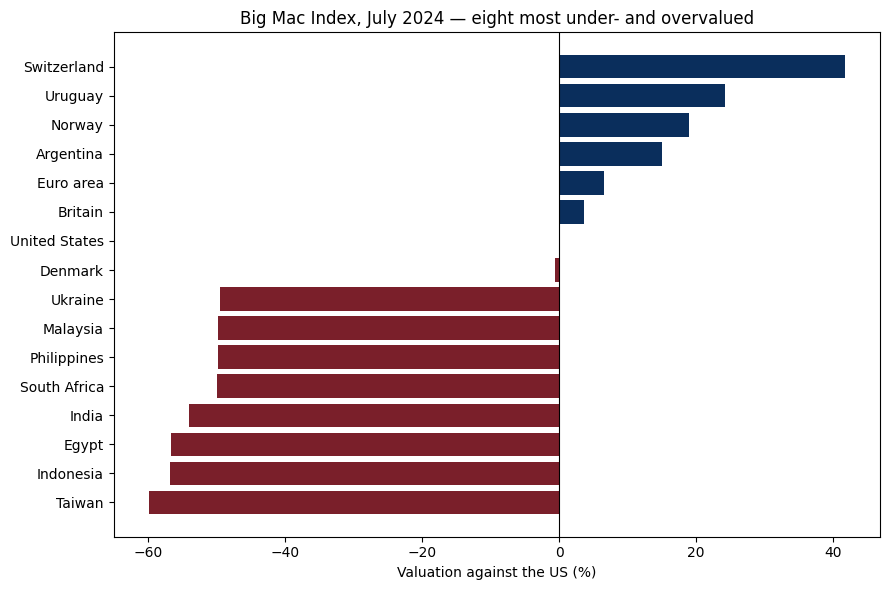

Median valuation: -20.7%
Dearer than the US: 6 of 54
The United States is the benchmark, so its bar is exactly 0 by
construction -- not a missing value.
Saved to figures/ch01_valuation.png


In [63]:
# -----------------------------------------------------------
# GUIDED — Run as-is
# Step 2b: see the corrected ranking
# -----------------------------------------------------------
# This reads `df_2024` AFTER your fix. If the chart still puts Taiwan and
# Indonesia at the top, the bug is still there — go back one cell.

from pathlib import Path
Path("figures").mkdir(exist_ok=True)   # Colab starts with no figures/ folder

ranked = df_2024.dropna(subset=["valuation_pct"]).sort_values("valuation_pct")
ends = pd.concat([ranked.head(8), ranked.tail(8)])

# A list comprehension with a ternary — read it, do not worry about writing it.
# It says: red where the value is negative, blue where it is positive.
colors = ["#7a1f2a" if v < 0 else "#0a2e5c" for v in ends["valuation_pct"]]

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(ends["name"], ends["valuation_pct"], color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Valuation against the US (%)")
ax.set_title("Big Mac Index, July 2024 — eight most under- and overvalued")
plt.tight_layout()
plt.savefig("figures/ch01_valuation.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Median valuation: {df_2024['valuation_pct'].median():.1f}%")
print(f"Dearer than the US: {int((df_2024['valuation_pct'] > 0).sum())} of {len(df_2024)}")
print("The United States is the benchmark, so its bar is exactly 0 by\n"
      "construction -- not a missing value.")
print("Saved to figures/ch01_valuation.png")

### The economics behind the ranking

The bug was arithmetic. These three are not — they ask what the corrected
chart actually means. Question 3 is the one worth most of your time.

1. **Why are most countries undervalued against the US?** What does that tell
   you about the US price level — and about the Big Mac as a *measuring
   instrument*?
2. **Switzerland has been the most overvalued in every period since 2015.** Which non-tradeable
   inputs explain it? (rent, wages, protection, tax)
3. **Critical.** If a hedge fund used this chart to place currency bets, would
   you expect it to make money? Why or why not?

*Your answers here:*

1. most are undervalued because the big mac costs less when converted to USD. this shows that the U.S. has a generally higher price level with higher wages, rent, etc. that is driving the price of the big mac up. the big mac index is not represenative of currency valuation against the U.S. dollar because it is not a standardized commodity; the price can be affected by cost of living differences, taxes, McDonald's pricing strategy in differing countries, etc.
2. rent: commercial spaces are expensive to rent especially in popular or big Swiss cities. wages: restaurant workers in Switzerland get paid significantly higher wages than U.S. employees. protection: agricultural protection and tariffs increase the cost of ingredients such as dairy and beef. all of these are hiking up the price of the big mac in Switzerland even if the Swiss franc is in reality not that strong compared to USD.
3. i would not expect a hedge fund to make lots of money from this chart because purchasing power parity is a long term valuation concept and hedge funds typically take advantage of short term arbitrage; currencies can be under or overvalued for years due to various reasons (interest rates, inflation expectations, government policies).


## Part 2: Find the Methodological Flaw — Missing Data Handling (10 min)

The following analysis handles missing data before computing summary statistics.
The code runs correctly. The methodology is wrong. Find the flaw.

In [64]:
# -----------------------------------------------------------
# GUIDED — Run as-is (contains methodological flaw)
# Step 3: Missing data handling with flawed reasoning
# -----------------------------------------------------------

# Count observations per country
max_periods = df["date"].nunique()
country_counts = df.groupby("name")["date"].count()
incomplete = country_counts[country_counts < max_periods]

print(f"Countries with incomplete panels: {len(incomplete)}")
print(incomplete.sort_values())
print()

# "Solution": drop all countries with ANY missing periods
complete_countries = country_counts[country_counts == max_periods].index
df_clean = df[df["name"].isin(complete_countries)].copy()

print(f"Dropped {df['name'].nunique() - df_clean['name'].nunique()} countries")
print(f"Remaining: {df_clean['name'].nunique()} countries with complete panels")
print()

# Compute average dollar price over time
avg_price = df_clean.groupby("date")["dollar_price"].mean()
print("Average Big Mac price (complete-panel countries only):")
print(avg_price.tail())
print()
print("CONCLUSION: The global average Big Mac price has risen steadily.")
print("This represents the true trend for ALL countries worldwide.")

Countries with incomplete panels: 32
name
Azerbaijan              17
Bahrain                 17
Guatemala               17
Honduras                17
Lebanon                 17
Moldova                 17
Jordan                  17
Kuwait                  17
Nicaragua               17
Romania                 17
Qatar                   17
Oman                    17
United Arab Emirates    17
UAE                     22
Vietnam                 25
India                   31
Venezuela               31
Sri Lanka               35
Russia                  36
Israel                  36
Costa Rica              39
Ukraine                 39
Saudi Arabia            40
Colombia                40
Uruguay                 40
Pakistan                40
Norway                  41
Egypt                   42
Peru                    42
Turkey                  43
Denmark                 44
Philippines             44
Name: date, dtype: int64

Dropped 32 countries
Remaining: 25 countries with complete panels

A

### YOUR DIAGNOSIS

Five questions. Measure the answer to 4 in the next cell, then write all five
in the *Document your diagnosis* cell after it.
Three and five are the ones this course is really asking about.

1. **What is the methodological flaw?** The code runs and the arithmetic is
   right. The reasoning is wrong.
2. **Which countries were dropped — are they a random subset?** Read the
   printed list before you characterise it.
3. **Which missing data mechanism is at work?** MCAR, MAR, or MNAR — and
   check whether one label covers every gap in this panel.
4. **Which direction is the "global average" biased, and by how much?**
   Measure it in the next cell rather than arguing about it.
5. **Propose a better approach** that acknowledges the missing data instead of
   silently dropping it.

**Checkpoint — 32 of 57 dropped, 25 kept.** Before writing "emerging markets get
dropped", check three names in the output above: **Argentina** is *kept* (all 45
periods), while **Norway** (41) and **Denmark** (44) are *dropped*. The filter
selects on continuity of measurement, not on development — and it conflates
three different things. Some countries **left** the index (Russia, last priced
January 2022; Sri Lanka, January 2024). Some **joined late** (the Gulf and
Central American block, 17 periods each from July 2018). And some have **gaps
in the middle** of a run that is still going (Venezuela 31, Ukraine 39 — both
priced in July 2026). Check first and last dates before you assign a country
to a group. Two traps in the names: `UAE` (to January 2018) and `United Arab
Emirates` (from July 2018) are one country renamed, and `Euro area` is not a
country — so the 57 names are 56 ISO codes and 55 economies. That split
matters for question 3.

In [65]:
# -----------------------------------------------------------
# ✏️ YOUR TASK — Demonstrate the bias
# Two blanks. Both use variables the cell above already made.
# -----------------------------------------------------------

# (a) the flawed approach — complete-panel countries only     [Step 0c]
#     `df_clean` above is already filtered to those 25.
complete_only = df_clean.groupby("date")["dollar_price"].mean()

# (b) the honest one — every country available in each period [Step 0c]
all_available = df.groupby("date")["dollar_price"].mean()

# The gap between the two IS the bias. Nothing below needs editing.
gap = complete_only - all_available
print(f"mean overstatement: ${gap.mean():+.3f}   ({(gap / all_available).mean():+.1%})")
print(f"complete-panel average is higher in {int((gap > 0).sum())} of {len(gap)} periods")
print("\nlast six periods      complete   all avail.      gap")
for d in complete_only.index[-6:]:
    print(f"  {str(d.date()):<16}{complete_only[d]:>9.3f}{all_available[d]:>12.3f}{gap[d]:>+9.3f}")

mean overstatement: $+0.081   (+2.1%)
complete-panel average is higher in 33 of 45 periods

last six periods      complete   all avail.      gap
  2024-01-01          4.456       4.381   +0.075
  2024-07-01          4.558       4.427   +0.131
  2025-01-01          4.527       4.434   +0.093
  2025-07-01          4.864       4.736   +0.128
  2026-01-01          5.058       4.900   +0.158
  2026-07-01          5.151       5.092   +0.059


In [66]:
# -----------------------------------------------------------
# CHECK — Run as-is after the two blanks
# -----------------------------------------------------------
# A per-date mean times the per-date count must give back the per-date total
# of the frame it came from. That pins each series to its source frame without
# naming the expression.
for label, series, frame in [("complete_only", complete_only, df_clean),
                             ("all_available", all_available, df)]:
    assert isinstance(series, pd.Series), f"{label} should be a Series indexed by date."
    n = frame.groupby("date").size()
    total = frame.groupby("date")["dollar_price"].sum()
    assert series.index.equals(total.index), (
        f"{label} is not indexed by the {total.index.size} dates of its frame.")
    assert np.allclose(series * n, total), (
        f"{label} is not the average dollar price, per date, of "
        f"{'df_clean' if frame is df_clean else 'df'}.")
print("Part 2 check passed.")

Part 2 check passed.


**Measured** (The Economist's live file; the last decimal moves when they
revise): mean overstatement **+\$0.081 (+2.1%)**, and the complete-panel
average is higher in **33 of 45** periods.

### Document your diagnosis

*Your answers to the five questions here:*

1. **The flaw** —

this is not random because it only includes countries that are observed in all 45 periods rather than all the countries meaning the conclusion is drawn from the 25 countries kept in the sample and is not truly representative of the world.

2. **Who was dropped, and is it random** —

the 32 dropped are not only the emerging markets; any countries that joined late, left early, had internal gaps, etc. were all dropped so it was not random.

3. **Which mechanism (MCAR / MAR / MNAR)** —

it is a mix of MAR and MNAR, not MCAR. MAR from countries joining late or leaving early that can be observed, MNAR from wars, sanctions, hyperinflation, etc.

4. **Direction and size of the bias** —

upward bias overstating the average price by 0.081 or 2.1% producing a higher estimate in 33 of 45 periods.

5. **A better approach** —

calculate each date separately based on the countries observed at that time, and keep all countries rather than dropping countries with missing periods.

## Part 3: Data Structure Profiling (GUIDED + YOUR TASK — 14 min)

Part 2 was about rows that are missing. This part is about what the *shape* of
the data tells you before you model anything. The guided cell first, then you
package it into a function.


In [67]:
# -----------------------------------------------------------
# GUIDED — Run as-is
# Step 4: the same data, sliced three ways
# -----------------------------------------------------------
# Step 0c counted 57 units and 45 periods. Those two numbers are what decide
# which of the three structures you are holding — and all three come out of
# THIS ONE FRAME, depending on how you slice it.

# CROSS-SECTIONAL — many units, one period.
cross = df[df["date"] == "2024-07-01"]
print(f"Cross-sectional : {cross['name'].nunique():>3} countries x "
      f"{cross['date'].nunique()} period   -> {len(cross):>4} rows")

# TIME SERIES — one unit, many periods.
series = df[df["name"] == "Switzerland"]
print(f"Time series     : {series['name'].nunique():>3} country   x "
      f"{series['date'].nunique()} periods -> {len(series):>4} rows")

# PANEL — many units, many periods. Both counts above 1.
print(f"Panel (all)     : {df['name'].nunique():>3} countries x "
      f"{df['date'].nunique()} periods -> {len(df):>4} rows")

# And the gap that makes this panel UNBALANCED:
full = df["name"].nunique() * df["date"].nunique()
print(f"\nIf every country appeared in every period: {full:,} rows")
print(f"Actually present:                          {len(df):,} rows")
print(f"Absent:                                    {full - len(df):,} "
      f"({1 - len(df)/full:.1%} of the grid)")
print("\nThose missing rows are the subject of Part 2. Note that they are")
print("ABSENT, not null -- no .isna() check anywhere will find them.")

Cross-sectional :  54 countries x 1 period   ->   54 rows
Time series     :   1 country   x 45 periods ->   45 rows
Panel (all)     :  57 countries x 45 periods -> 2056 rows

If every country appeared in every period: 2,565 rows
Actually present:                          2,056 rows
Absent:                                    509 (19.8% of the grid)

Those missing rows are the subject of Part 2. Note that they are
ABSENT, not null -- no .isna() check anywhere will find them.


In [68]:
# -----------------------------------------------------------
# ✏️ YOUR TASK — Profile the structure of any DataFrame
# Five blanks, one line each. Replace every ____
# -----------------------------------------------------------

def profile_dataframe(data, unit_col="name", time_col="date"):
    """Return a dict describing the structure and completeness of `data`."""
    profile = {}
    profile["shape"] = data.shape

    # 1. How many units, and how many periods?                    [Step 0c]
    profile["n_units"]   = data[unit_col].nunique()
    profile["n_periods"] = data[time_col].nunique()

    # The taxonomy follows from those two counts. Read this; it is the
    # whole point of the chapter.
    if profile["n_units"] > 1 and profile["n_periods"] > 1:
        profile["structure"] = "panel"
    elif profile["n_periods"] > 1:
        profile["structure"] = "time series"
    else:
        profile["structure"] = "cross-sectional"

    # 2. Count the periods each unit actually appears in.         [Step 0c]
    periods_per_unit = data.groupby(unit_col)[time_col].nunique()

    # 3. Keep only the units that appear in every period, and say whether
    #    that is all of them.                                     [Step 0c]
    complete = periods_per_unit[periods_per_unit == profile["n_periods"]]
    profile["complete_units"] = len(complete)
    profile["balanced"] = len(complete) == profile["n_units"]

    # 4. The share of each column that is missing, as a percentage.
    #    One entry per column, built with the loop.               [Step 0d]
    missing = {}
    for col in data.columns:
        missing[col] = data[col].isna().mean() * 100
    profile["missing"] = missing

    return profile


# --- run it on the Big Mac panel ---
result = profile_dataframe(df)
for key in result:
    if key != "missing":
        print(f"  {key:<16} {result[key]}")

n_gappy = 0
for col in result["missing"]:
    if result["missing"][col] > 10:
        n_gappy += 1
print(f"  {'cols >10% missing':<16} {n_gappy}")

  shape            (2056, 19)
  n_units          57
  n_periods        45
  structure        panel
  complete_units   25
  balanced         False
  cols >10% missing 7


In [69]:
# -----------------------------------------------------------
# CHECK — Run as-is after the blanks
# -----------------------------------------------------------
# Toy frames with answers you can verify by eye, so the check does not depend
# on the Big Mac file and does not print the Big Mac answer.
toy = pd.DataFrame({"name": ["A", "A", "B", "B", "C"],
                    "date": ["t1", "t2", "t1", "t2", "t1"],
                    "x":    [1.0, None, 3.0, 4.0, 5.0]})
p = profile_dataframe(toy)
assert (p["n_units"], p["n_periods"]) == (3, 2), (
    f"toy has 3 units and 2 periods; got {p['n_units']} and {p['n_periods']}.")
assert p["complete_units"] == 2, f"toy has 2 complete units; got {p['complete_units']}."
assert isinstance(p["balanced"], (bool, np.bool_)), "balanced should be True or False."
assert not p["balanced"], "toy is unbalanced (C is missing t2), but balanced is True."
assert np.isclose(p["missing"]["x"], 20.0), (
    f"x is missing 1 value in 5 = 20 percent; got {p['missing']['x']}.")

square = toy[toy["name"] != "C"]
assert profile_dataframe(square)["balanced"], "A and B both have t1 and t2, so it is balanced."
print("Part 3 check passed.")

Part 3 check passed.


**Measured on the Big Mac panel:** 57 units, 45 periods, panel, 25 complete,
balanced False, 7 columns more than 10% missing.

---

### Where the module work went

An earlier version of this lab asked you to package `profile_dataframe()` and
two more functions into an importable `data_utils.py`, with type hints, full
docstrings and assertions.

That belongs in **Lab 2**, not here. Step 0e gave you enough of `def` to write
the function Part 3 asks for -- parameters, a default, a docstring, `return`.
Lab 2's Part 0 takes it further, to `raise` and the two routes a notebook uses
to write a real `.py` file, and its Part 4 builds one. Writing the module now
would put the packaging before the practice.

Keep the `profile_dataframe()` you wrote in Part 3. Lab 2 Part 4 picks it up.


---
## Digital Portfolio: Institutional Signaling

### Generate Your Professional README
Copy and paste the prompt below into Claude or ChatGPT. **Do NOT ask the AI to write Python code — only documentation.**

In [70]:
# -----------------------------------------------------------
# 🤖 README generation — AI writes the docs, not the code
# -----------------------------------------------------------

# PASTE THIS PROMPT INTO CLAUDE:
#
# "I need help writing a project description for my data science lab.
# **Important Rule:** Do NOT generate any Python code for me.
#
# **What I did in this lab:**
# * Diagnosed and fixed a PPP computation bug (swapped numerator/denominator)
# * Identified survivorship bias from dropping incomplete panels
# * Quantified the bias: the complete-panel average Big Mac price is $X.XX
#   (X.X%) above the all-available average, and higher in XX of 45 periods.
#   [Copy these three numbers from my own Part 2 output.]
# * Wrote profile_dataframe(), which reports units, periods, structure,
#   complete units, balance and per-column missing percentages
#   Write only what my own output says, not what I expected it to say.
#
# **Please write a README.md entry including:**
# 1. Project Title: Data Quality Profiling — Big Mac Index
# 2. Objective: A professional one-sentence summary
# 3. Methodology: Bullet points of technical steps
# 4. Key Findings: Summary of results
# Make this sound like a professional tech economist wrote it."

---

## Submit this lab on GitHub

**Repository name for this lab:** `econ5200-lab01-data-portfolio`

**First time?** Read the **GitHub Setup and Repository Guide** page in the Start Here module once,
start to finish. It assumes you have never used git and never seen GitHub.

1. On [github.com](https://github.com): **+** (top right) → **New repository**.
   Name it exactly `econ5200-lab01-data-portfolio`, tick **Add a README file**, and create it.
2. **Run the whole notebook top to bottom** (**Runtime → Run all**) and check your
   output is showing. The rendered output — charts included — is what is graded.
3. In Colab: **File → Save a copy in GitHub**.
   - **First time only:** a GitHub window asks you to authorize Colab. Sign in, then
     authorize. **If your repo is Private, tick the box granting access to private
     repositories first** — otherwise Colab won't list your repo.
   - Choose `econ5200-lab01-data-portfolio`, branch `main`, commit message
     `Lab 01 submission`, tick **Include a link to Colab**, and click **OK**.
4. Open the repo on github.com, click `README.md`, then the pencil icon, and
   paste in the README you drafted from the prompt above. **Commit
   changes.** Check every number in it against your own output first: this
   goes out under your name.
5. On Canvas: in Colab use **File → Download → Download .ipynb**, upload that
   file to the assignment, and paste your **repository** URL in the **Comments**
   box — `https://github.com/yourname/econ5200-lab01-data-portfolio`, not the
   link to the notebook file. Then click **Submit**. Do not use the Website URL
   tab: Canvas keeps one submission, so a URL sent on its own replaces your
   notebook.

No terminal, no token, nothing to install. Stuck? The GitHub Setup and Repository Guide page has a
Troubleshooting section.
